## Fusion Retrieval in Document Search

### Overview
This code implements a Fusion Retrieval system that combines vector-based similarity search with keyword-based BM25 retrieval. The approach aims to leverage the strengths of both methods to improve the overall quality and relevance of document retrieval.

### Key Components
1. PDF processing and text chunking
2. Vector store creation using FAISS and Bedrock embeddings
3. BM25 index creation for keyword-based retrieval
4. Custom fusion retrieval function that combines both methods

### Method Details
#### Document Preprocessing
1. The PDF is loaded and split into chunks using RecursiveCharacterTextSplitter.
2. Chunks are cleaned by replacing 't' with spaces (likely addressing a specific formatting issue).
#### Vector Store Creation
1. Bedrock embeddings are used to create vector representations of the text chunks.
2. A FAISS vector store is created from these embeddings for efficient similarity search.
#### BM25 Index Creation
1. A BM25 index is created from the same text chunks used for the vector store.
2. This allows for keyword-based retrieval alongside the vector-based method.
#### Fusion Retrieval Function
The `fusion_retrieval` function is the core of this implementation:
1. It takes a query and performs both vector-based and BM25-based retrieval.
2. Scores from both methods are normalized to a common scale.
3. A weighted combination of these scores is computed (controlled by the `alpha` parameter).
4. Documents are ranked based on the combined scores, and the top-k results are returned.

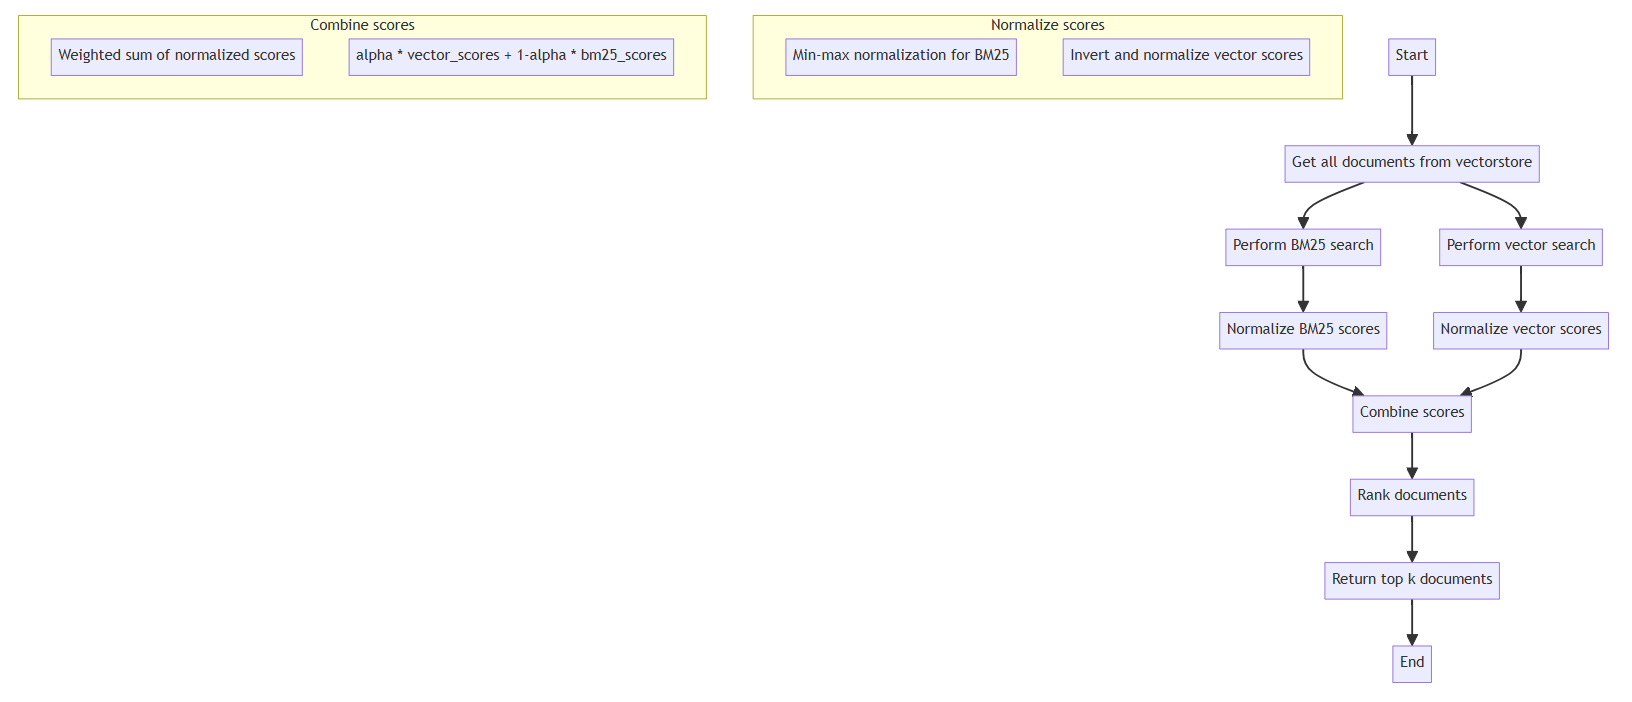

### Imports

In [1]:
import os
print(os.listdir('.'))

['fusion_retrieval.ipynb', 'reranking.ipynb']


In [2]:
import sys
from langchain_core.documents import Document
from rank_bm25 import BM25Okapi
from typing import List
from dotenv import load_dotenv
load_dotenv()
sys.path.append('../')  # Go up one level
from helper_functions import *

c:\Users\birok\Python\MLOPs\RAG-Techniques\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Define document path

In [10]:
path=r"C:\Users\birok\Python\MLOPs\RAG-Techniques\data\Understanding_Climate_Change.pdf"

### Encode the pdf to vector store and return split document from the step before to create BM25 instance

In [11]:
def encode_pdf_and_get_split_documents(path: str, chunk_size: int=1000, chunk_overlap: int=200):
    """Encodes a PDF book into a vector store using OpenAI embeddings.

    Args:
        path: The path to the PDF file.
        chunk_size: The desired size of each text chunk.
        chunk_overlap: The amount of overlap between consecutive chunks.

    Returns:
        A FAISS vector store containing the encoded book content."""
    # Load PDF documents
    loader= PyPDFLoader(path)
    documents=loader.load()

    # Split documents into chunks
    text_splitter= RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap, length_function=len)
    texts= text_splitter.split_documents(documents=documents)
    cleaned_texts= replace_t_with_space(texts)

    # Create embeddings and vector store
    embeddings= BedrockEmbeddings(model_id='amazon.titan-embed-text-v2:0')
    vectorstore= FAISS.from_documents(cleaned_texts, embeddings)

    return vectorstore, cleaned_texts



### Create the vectorstore and get the chunked documents

In [12]:
vectorstore, cleaned_texts= encode_pdf_and_get_split_documents(path)

### Create a bm25 index for retrieving documents by keywords

In [13]:
def create_bm25_index(documents: List[Document])->BM25Okapi:
    """
    Crete a BM25 from the given documents.
    BM25(Best Match 25) is a ranking function used in information retrieval.
    It's based om the probablistic retrieval framework and is an improvement over TF-IDF.
    Args:
    documents(List[Document]): List of documents to index.
    
    Returns:
    BM250kapi: An index that can be used for BM25 scoring.
    """
    # Tokenize each document by splitting on whitespace
    # This is a simple approach and could be improved with more sophisticated tokenization
    tokenized_docs= [doc.page_content.split() for doc in documents]
    return BM25Okapi(tokenized_docs)

In [14]:
bm25= create_bm25_index(cleaned_texts) # Create BM25 index from the cleaned text (chunks)

### Define a function that retrieves both semantically and by keyword, normalizes the scores and gets the top k documents

In [22]:
def fusion_retrieval(vectorstore,bm25,documents,query: str,k: int = 5,alpha: float = 0.5,candidate_k: int = 50):
    """
    Perform hybrid (fusion) retrieval by combining BM25 keyword search and
    vector-based semantic search.

    This function retrieves candidate documents from both retrieval systems,
    normalizes their scores, and combines them using weighted score fusion.

    The final score for each document is computed as:

        final_score = alpha * vector_score + (1 - alpha) * bm25_score

    where:
        - vector_score represents semantic similarity from the vector store
        - bm25_score represents keyword relevance from the BM25 index

    To improve efficiency, the function first retrieves a limited number of
    candidate documents from both retrievers (`candidate_k`) and then performs
    fusion ranking only on the combined candidate pool.

    Args:
        vectorstore (VectorStore):
            A vector database (e.g., FAISS) containing embedded documents
            used for semantic similarity search.

        bm25 (BM25Okapi):
            A precomputed BM25 index built from the same document corpus
            used by the vector store.

        documents (List[Document]):
            The original list of documents used to build the BM25 index.
            This is required to map BM25 scores back to the document objects.

        query (str):
            The user query used to retrieve relevant documents.

        k (int, optional):
            The number of top-ranked documents to return after fusion.
            Default is 5.

        alpha (float, optional):
            Weight assigned to the vector search score in the final fusion.
            Must be between 0 and 1.

            Example:
                alpha = 0.7
                → 70% vector relevance
                → 30% BM25 relevance

        candidate_k (int, optional):
            Number of candidate documents retrieved independently from
            BM25 and vector search before fusion ranking.
            Increasing this value may improve recall but increases compute.

    Returns:
        List[Document]:
            A list of the top-k documents ranked by the combined
            fusion score.

    Notes:
        - Score normalization is applied to both BM25 and vector scores
        before fusion to ensure they are comparable.
        - A candidate pooling strategy is used to avoid scoring the entire
        corpus, improving scalability for large document collections.
        - This method implements **weighted score fusion**, which is one of
        several hybrid retrieval strategies used in RAG systems.
    """

    epsilon = 1e-8

    # ---- Step 1: BM25 Retrieval ----
    query_tokens = query.split()
    bm25_scores = bm25.get_scores(query_tokens)

    bm25_top_indices = np.argsort(bm25_scores)[::-1][:candidate_k]

    # ---- Step 2: Vector Retrieval ----
    vector_results = vectorstore.similarity_search_with_score(query, k=candidate_k)

    vector_docs = [doc for doc, _ in vector_results]
    vector_scores = np.array([score for _, score in vector_results])

    # ---- Step 3: Normalize Vector Scores ----
    vector_scores = 1 - (vector_scores - np.min(vector_scores)) / (
        np.max(vector_scores) - np.min(vector_scores) + epsilon
    )

    # ---- Step 4: Build Candidate Pool ----
    candidate_docs = {doc.page_content: doc for doc in vector_docs}

    for idx in bm25_top_indices:
        candidate_docs[documents[idx].page_content] = documents[idx]

    candidate_docs = list(candidate_docs.values())

    # ---- Step 5: Compute Combined Scores ----
    combined_scores = []

    for doc in candidate_docs:

        # BM25 score
        try:
            bm25_index = documents.index(doc)
            bm25_score = bm25_scores[bm25_index]
        except:
            bm25_score = 0

        # vector score
        vector_score = 0
        for i, vdoc in enumerate(vector_docs):
            if vdoc.page_content == doc.page_content:
                vector_score = vector_scores[i]
                break

        score = alpha * vector_score + (1 - alpha) * bm25_score
        combined_scores.append((doc, score))

    # ---- Step 6: Rank ----
    combined_scores.sort(key=lambda x: x[1], reverse=True)

    return [doc for doc, _ in combined_scores[:k]]

### Usecase example

In [24]:
# Query
query= "What are the impacts of climate change on the environment?"

# Perform fusion retrieval
top_docs= fusion_retrieval(query=query, vectorstore=vectorstore, bm25=bm25, documents=cleaned_texts, k=5, alpha=0.5, candidate_k=50)
docs_content=[doc.page_content for doc in top_docs]
show_context(docs_content)

Context 1:
cultural perceptions. 
Youth Engagement 
Youth are vital stakeholders in climate action. Empowering young people through education, 
activism, and leadership opportunities can drive transformative change. Youth movements, 
such as Fridays for Future, demonstrate the power of young voices in advocating for a 
sustainable future. 
By continuing to innovate, collaborate, and commit to sustainable practices, we can mitigate 
the impacts of climate change and build a resilient, equitable, and thriving world for future 
generations. The journey ahead requires dedication, creativity, and collective effort from all 
sectors of society. 
Chapter 9: Climate Change and Biodiversity 
Impact on Ecosystems 
Terrestrial Ecosystems 
Climate change is altering terrestrial ecosystems by shifting habitat ranges, changing species 
distributions, and impacting ecosystem functions. Forests, grasslands, and deserts are


Context 2:
Tropical rainforests are particularly important for carbon storage

### Reciprocal Rank Fusion

In [26]:
def rrf_retrieval(vectorstore,bm25,documents,query: str,k: int = 5,candidate_k: int = 50,rrf_k: int = 60) -> List[Document]:
    """
    Perform hybrid retrieval using Reciprocal Rank Fusion (RRF).
    This method combines the ranked outputs of multiple retrieval systems
    (BM25 keyword search and vector semantic search) using the RRF formula:

        RRF(d) = Σ 1 / (rrf_k + rank_i(d))

    where:
        - rank_i(d) is the rank position of document d in retriever i
        - rrf_k is a smoothing constant (typically 60)

    Unlike score fusion, RRF relies only on rank positions rather than
    raw retrieval scores, making it more robust across different retrieval
    systems.

    Args:
        vectorstore (VectorStore):
            A vector database (e.g., FAISS) containing embedded documents
            used for semantic similarity search.

        bm25 (BM25Okapi):
            A precomputed BM25 index built from the same document corpus.

        documents (List[Document]):
            Original document list used to build the BM25 index.

        query (str):
            The user query.

        k (int, optional):
            Number of final documents to return.

        candidate_k (int, optional):
            Number of top candidates retrieved from each retriever
            before fusion.

        rrf_k (int, optional):
            Constant used in RRF scoring. Higher values reduce the
            influence of rank differences.

    Returns:
        List[Document]:
            Top-k documents ranked by RRF score.
    """

    from collections import defaultdict

    # ----- BM25 Retrieval -----
    query_tokens = query.split()
    bm25_scores = bm25.get_scores(query_tokens)
    bm25_top_indices = np.argsort(bm25_scores)[::-1][:candidate_k]

    bm25_ranked_docs = [documents[i] for i in bm25_top_indices]

    # ----- Vector Retrieval -----
    vector_results = vectorstore.similarity_search(query, k=candidate_k)
    vector_ranked_docs = vector_results

    # ----- RRF Scoring -----
    rrf_scores = defaultdict(float)

    for rank, doc in enumerate(bm25_ranked_docs, start=1):
        rrf_scores[doc.page_content] += 1 / (rrf_k + rank)

    for rank, doc in enumerate(vector_ranked_docs, start=1):
        rrf_scores[doc.page_content] += 1 / (rrf_k + rank)

    # ----- Combine Candidate Documents -----
    candidate_docs = {doc.page_content: doc for doc in bm25_ranked_docs}
    for doc in vector_ranked_docs:
        candidate_docs[doc.page_content] = doc

    # ----- Rank by RRF Score -----
    ranked_docs = sorted(
        candidate_docs.values(),
        key=lambda doc: rrf_scores[doc.page_content],
        reverse=True
    )

    return ranked_docs[:k]


In [28]:
results = rrf_retrieval(
    vectorstore,
    bm25,
    cleaned_texts,
    query="climate change impacts",
    k=5
)
for i, doc in enumerate(results, start=1):
    print(f"Rank {i}:\n{doc.page_content}\n{'-'*50}\n")

Rank 1:
Local communities are often on the front lines of climate impacts and can be powerful agents 
of change. Community-based conservation projects involve residents in protecting and 
restoring natural resources, such as forests, wetlands, and coastal areas. These projects 
enhance local resilience and biodiversity. 
Education and Awareness 
Raising public awareness about climate change and sustainability is crucial for driving action. 
Educational programs, media campaigns, and community events can inform and inspire 
individuals to adopt environmentally friendly practices. Schools, NGOs, and local 
governments play key roles in these efforts. 
Chapter 7: The Economics of Climate Change 
Costs of Inaction 
Economic Impacts of Climate Change 
The economic costs of climate change include damage to infrastructure, reduced agricultural 
productivity, health care costs, and lost labor productivity. Extreme weather events, such as
--------------------------------------------------

Rank